## 1

Perceptron classification accuracy 1.0


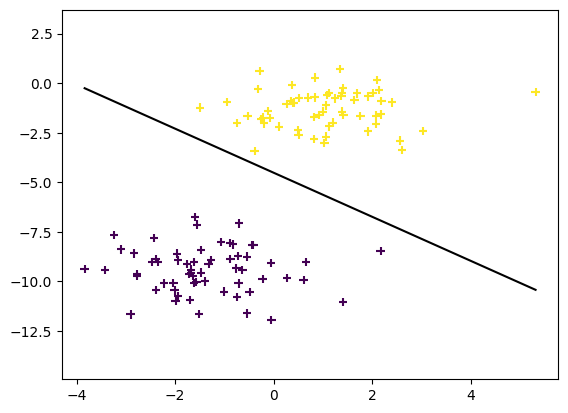

In [10]:
import numpy as np
def unit_step_func(x):
    return np.where(x > 0 , 1, 0)
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = unit_step_func
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        y_ = np.where(y > 0 , 1, 0)
        # learn weights
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)
                # Perceptron update rule
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias

        y_predicted = self.activation_func(linear_output)
        return y_predicted


# Testing
if __name__ == "__main__":
    # Imports
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn import datasets
    def accuracy(y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    X, y = datasets.make_blobs(
        n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=123
    )
    p = Perceptron(learning_rate=0.01, n_iters=1000)
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)
    print("Perceptron classification accuracy", accuracy(y_test, predictions))
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    plt.scatter(X_train[:, 0], X_train[:, 1], marker="+", c=y_train)
    x0_1 = np.amin(X_train[:, 0])
    x0_2 = np.amax(X_train[:, 0])
    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]
    ax.plot([x0_1, x0_2], [x1_1, x1_2], "k")
    ymin = np.amin(X_train[:, 1])
    ymax = np.amax(X_train[:, 1])
    ax.set_ylim([ymin - 3, ymax + 3])
    plt.show()


Perceptron classification accuracy 1.0


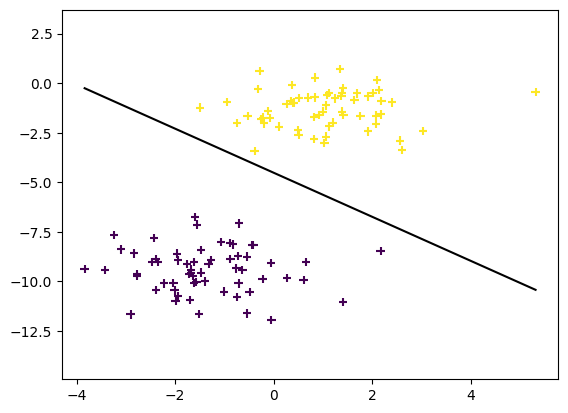

In [11]:
## compressed version for 1
import numpy as np

step = lambda x: np.where(x > 0, 1, 0)

class Perceptron:
    def __init__(self, lr=0.01, n=1000):
        self.lr, self.n = lr, n

    def fit(self, X, y):
        self.w, self.b = np.zeros(X.shape[1]), 0
        y = np.where(y > 0, 1, 0)
        for _ in range(self.n):
            for i, x in enumerate(X):
                u = self.lr * (y[i] - step(np.dot(x, self.w) + self.b))
                self.w += u * x; self.b += u

    def predict(self, X):
        return step(np.dot(X, self.w) + self.b)


# Test
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    from sklearn import datasets
    from sklearn.model_selection import train_test_split

    acc = lambda y, p: np.mean(y == p)

    X, y = datasets.make_blobs(150, 2, centers=2, cluster_std=1.05, random_state=2)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=123)

    p = Perceptron()
    p.fit(Xtr, ytr)
    pred = p.predict(Xte)

    print("Perceptron classification accuracy", acc(yte, pred))

    x1, x2 = Xtr[:,0].min(), Xtr[:,0].max()
    y1, y2 = (-p.w[0]*x1 - p.b)/p.w[1], (-p.w[0]*x2 - p.b)/p.w[1]

    plt.scatter(Xtr[:,0], Xtr[:,1], c=ytr, marker="+")
    plt.plot([x1, x2], [y1, y2], "k")
    plt.ylim(Xtr[:,1].min()-3, Xtr[:,1].max()+3)
    plt.show()


## 2

Epoch 1/15
422/422 - 7s - 18ms/step - accuracy: 0.8428 - loss: 0.5482 - val_accuracy: 0.9562 - val_loss: 0.1599
Epoch 2/15
422/422 - 3s - 8ms/step - accuracy: 0.9219 - loss: 0.2659 - val_accuracy: 0.9672 - val_loss: 0.1139
Epoch 3/15
422/422 - 3s - 7ms/step - accuracy: 0.9372 - loss: 0.2110 - val_accuracy: 0.9742 - val_loss: 0.0902
Epoch 4/15
422/422 - 3s - 7ms/step - accuracy: 0.9461 - loss: 0.1784 - val_accuracy: 0.9757 - val_loss: 0.0816
Epoch 5/15
422/422 - 4s - 10ms/step - accuracy: 0.9523 - loss: 0.1589 - val_accuracy: 0.9752 - val_loss: 0.0808
Epoch 6/15
422/422 - 3s - 7ms/step - accuracy: 0.9574 - loss: 0.1403 - val_accuracy: 0.9773 - val_loss: 0.0739
Epoch 7/15
422/422 - 3s - 7ms/step - accuracy: 0.9601 - loss: 0.1320 - val_accuracy: 0.9808 - val_loss: 0.0667
Epoch 8/15
422/422 - 3s - 7ms/step - accuracy: 0.9619 - loss: 0.1215 - val_accuracy: 0.9817 - val_loss: 0.0667
Epoch 9/15
422/422 - 5s - 12ms/step - accuracy: 0.9652 - loss: 0.1129 - val_accuracy: 0.9812 - val_loss: 0.067

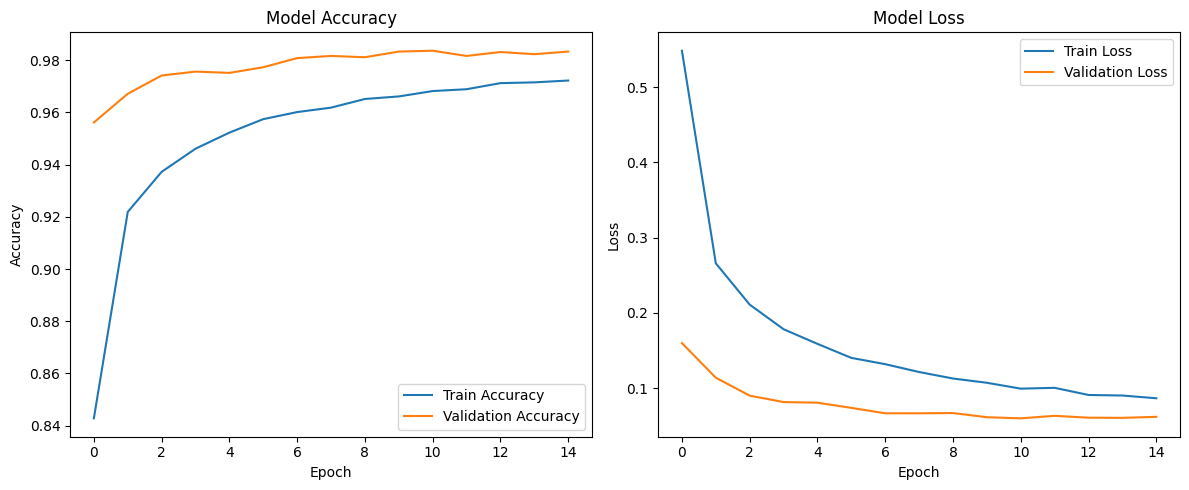


Model saved as 'mlp_mnist_model.h5'


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
# 2. Load and Preprocess the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Reshape the data (28x28 images → 784 features)
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build the MLP Model with Dropout and Batch Normalization
model = models.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# 5. Train the Model and Store Training History
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    verbose=2
)
# 6. Evaluate the Model on Test Data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# 7. Plot Training Curves (Accuracy and Loss)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Save the Trained Model
model.save("mlp_mnist_model.h5")
print("\nModel saved as 'mlp_mnist_model.h5'")


Epoch 1/15
422/422 - 5s - 13ms/step - accuracy: 0.8425 - loss: 0.5441 - val_accuracy: 0.9550 - val_loss: 0.1644
Epoch 2/15
422/422 - 3s - 7ms/step - accuracy: 0.9209 - loss: 0.2681 - val_accuracy: 0.9675 - val_loss: 0.1167
Epoch 3/15
422/422 - 5s - 12ms/step - accuracy: 0.9360 - loss: 0.2119 - val_accuracy: 0.9700 - val_loss: 0.0999
Epoch 4/15
422/422 - 3s - 7ms/step - accuracy: 0.9470 - loss: 0.1785 - val_accuracy: 0.9785 - val_loss: 0.0802
Epoch 5/15
422/422 - 3s - 7ms/step - accuracy: 0.9515 - loss: 0.1593 - val_accuracy: 0.9808 - val_loss: 0.0765
Epoch 6/15
422/422 - 4s - 9ms/step - accuracy: 0.9560 - loss: 0.1460 - val_accuracy: 0.9770 - val_loss: 0.0762
Epoch 7/15
422/422 - 3s - 7ms/step - accuracy: 0.9613 - loss: 0.1258 - val_accuracy: 0.9807 - val_loss: 0.0657
Epoch 8/15
422/422 - 3s - 7ms/step - accuracy: 0.9638 - loss: 0.1186 - val_accuracy: 0.9800 - val_loss: 0.0658
Epoch 9/15
422/422 - 3s - 7ms/step - accuracy: 0.9655 - loss: 0.1127 - val_accuracy: 0.9820 - val_loss: 0.0674

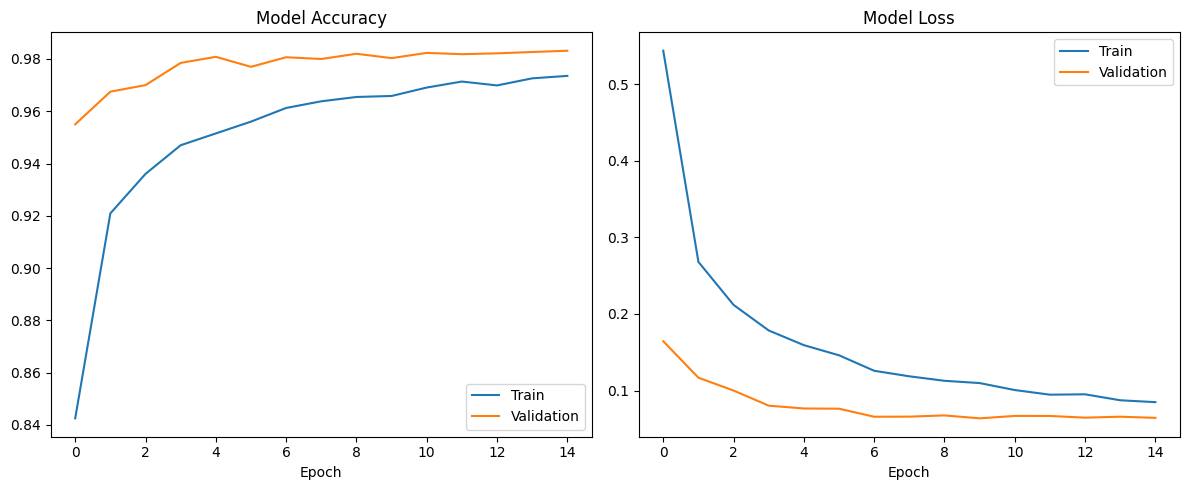


Model saved as 'mlp_mnist_model.h5'


In [13]:
# compresed version for 2
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load & preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.0
y_train, y_test = to_categorical(y_train, 10), to_categorical(y_test, 10)

# Build model
model = models.Sequential([
    layers.Dense(128, input_shape=(784,)),
    layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
    layers.Dense(64),
    layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile & train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=15, batch_size=128,
                    validation_split=0.1, verbose=2)

# Evaluate
acc = model.evaluate(x_test, y_test, verbose=0)[1]
print(f"\nTest Accuracy: {acc:.4f}")

# Plot metrics
plt.figure(figsize=(12,5))
for i, m in enumerate([('accuracy','Accuracy'), ('loss','Loss')], 1):
    plt.subplot(1,2,i)
    plt.plot(history.history[m[0]], label='Train')
    plt.plot(history.history['val_'+m[0]], label='Validation')
    plt.title(f"Model {m[1]}"); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# Save model
model.save("mlp_mnist_model.h5")
print("\nModel saved as 'mlp_mnist_model.h5'")


## 3 

In [14]:
#Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
# 2. Load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 3. Normalize Pixel Values (0–255 → 0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0
# 4. Convert Labels to One-Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
# 5. Function to Create and Train a Simple Model with Different Activations
def test_activation(activation):
    print(f"\nTraining with activation = {activation}")
    # Build Model
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation=activation),
        Dense(10, activation='softmax')
    ])
    # Compile Model
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    # Train Model (2 epochs for quick comparison)
    model.fit(x_train, y_train, epochs=2, batch_size=128, verbose=1)
    # Evaluate Model
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy with {activation}: {acc:.4f}")
# 6. Try Different Activation Functions
for act in ['relu', 'sigmoid', 'tanh']:
    test_activation(act)



Training with activation = relu
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8031 - loss: 0.7131
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9360 - loss: 0.2185
Test Accuracy with relu: 0.9528

Training with activation = sigmoid
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7129 - loss: 1.1956
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9108 - loss: 0.3385
Test Accuracy with sigmoid: 0.9261

Training with activation = tanh
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8002 - loss: 0.7077
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9328 - loss: 0.2387
Test Accuracy with tanh: 0.9432


In [15]:
#compressed version for 3
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load & preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# Train & evaluate model with different activations
def test_activation(act):
    print(f"\nTraining with activation = {act}")
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation=act),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=2, batch_size=128, verbose=1)
    acc = model.evaluate(x_test, y_test, verbose=0)[1]
    print(f"Test Accuracy with {act}: {acc:.4f}")

for act in ('relu', 'sigmoid', 'tanh'):
    test_activation(act)



Training with activation = relu
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7972 - loss: 0.7190
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9350 - loss: 0.2273
Test Accuracy with relu: 0.9483

Training with activation = sigmoid
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7365 - loss: 1.1472
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9104 - loss: 0.3354
Test Accuracy with sigmoid: 0.9246

Training with activation = tanh
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8092 - loss: 0.7018
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9326 - loss: 0.2362
Test Accuracy with tanh: 0.9441


## 4

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.3527 - loss: 1.7482 - val_accuracy: 0.5435 - val_loss: 1.2600
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.5584 - loss: 1.2260 - val_accuracy: 0.6097 - val_loss: 1.0948
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6259 - loss: 1.0576 - val_accuracy: 0.6474 - val_loss: 0.9880
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.6742 - loss: 0.9318 - val_accuracy: 0.6709 - val_loss: 0.9444
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7004 - loss: 0.8497 - val_accuracy: 0.6895 - val_loss: 0.8817
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.7289 - loss: 0.7750 - val_accuracy: 0.7046 - val_loss: 0.8725
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 48ms/step - accuracy: 0.7436 - loss: 0.7331 - val_accuracy: 0.6986 - val_loss: 0.8841
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.7621 -

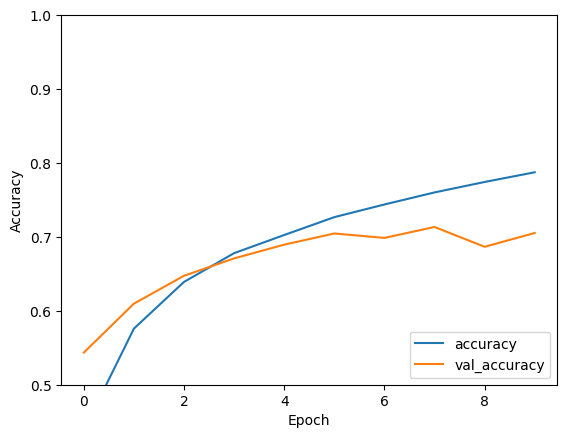

313/313 - 5s - 15ms/step - accuracy: 0.7053 - loss: 0.8910
Test Accuracy: 0.705299973487854
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
cat


In [16]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
# 1. Load and preprocess the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
# Define class names for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
# 2. Build the CNN model
model = models.Sequential()
# Convolutional Base
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Dense Layers (Classifier)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # Output layer with 10 units for 10 classes
# 3. Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
# 4. Train the model
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))
# 5. Evaluate the model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"Test Accuracy: {test_acc}")
# Make predictions on a sample image
predictions = model.predict(test_images)
print(class_names[tf.argmax(predictions[0])])


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 53ms/step - accuracy: 0.3560 - loss: 1.7337 - val_accuracy: 0.5482 - val_loss: 1.2664
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 48ms/step - accuracy: 0.5747 - loss: 1.2034 - val_accuracy: 0.6021 - val_loss: 1.1279
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6406 - loss: 1.0180 - val_accuracy: 0.6272 - val_loss: 1.0760
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.6773 - loss: 0.9180 - val_accuracy: 0.6649 - val_loss: 0.9560
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 50ms/step - accuracy: 0.7079 - loss: 0.8295 - val_accuracy: 0.6772 - val_loss: 0.9194
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7376 - loss: 0.7575 - val_accuracy: 0.6978 - val_loss: 0.8705
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7481 - loss: 0.7179 - val_accuracy: 0.7109 - val_loss: 0.8683
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 51ms/step - accuracy: 0.7693 

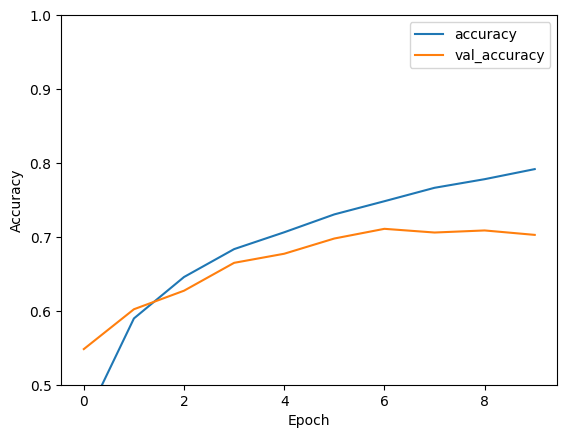

313/313 - 5s - 16ms/step - accuracy: 0.7027 - loss: 0.9130
Test Accuracy: 0.7027000188827515
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
cat


In [17]:
## compressed version for 4
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Load & normalize data
(x_tr, y_tr), (x_te, y_te) = datasets.cifar10.load_data()
x_tr, x_te = x_tr/255.0, x_te/255.0

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

# Model
model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

# Compile & train
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

h = model.fit(x_tr, y_tr, epochs=10, validation_data=(x_te, y_te))

# Plot accuracy
plt.plot(h.history['accuracy'], label='accuracy')
plt.plot(h.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.ylim([0.5,1]); plt.legend(); plt.show()

# Evaluate & predict
print("Test Accuracy:", model.evaluate(x_te, y_te, verbose=2)[1])
pred = model.predict(x_te)
print(classes[tf.argmax(pred[0])])


## 5

Precision: 0.75
Recall: 0.75
F1-Score: 0.75


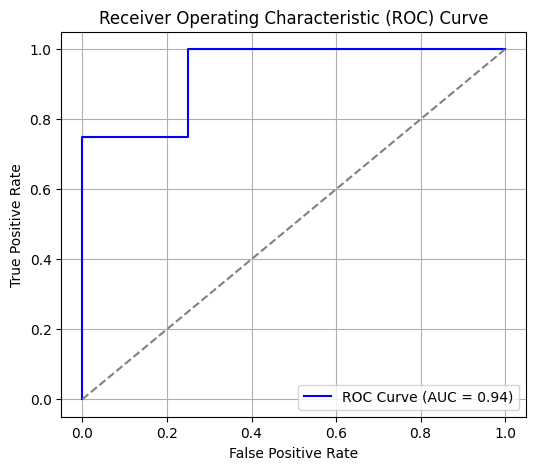

In [20]:
#Import Required Libraries
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
# 2. Define True Labels and Predicted Outputs
y_true = [1, 0, 1, 1, 0, 0, 1, 0]     # Actual class labels
y_pred = [1, 0, 1, 0, 0, 1, 1, 0]     # Predicted class labels
y_prob = [0.9, 0.2, 0.8, 0.4, 0.3, 0.7, 0.85, 0.1]   # Predicted probabilities (for ROC)
# 3. Calculate Evaluation Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
# 4. Display the Metrics
print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-Score:", round(f1, 2))
# 5. Generate ROC Curve Values
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
# 6. Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label="ROC Curve (AUC = %.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
